In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [40]:
df = pd.read_csv("hrtu_2.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [41]:
print("Null values:",df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Null values: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64
Duplicates: 0


In [42]:
df.columns = [
    "pf_mean",
    "pf_stdev",
    "pf_skew",
    "pf_kurt",
    "dm_mean",
    "dm_stdev",
    "dm_skew",
    "dm_kurt",
    "is_candidate"
]
print(df.head())
print(df.shape)
print(df["is_candidate"].value_counts())

      pf_mean   pf_stdev   pf_skew   pf_kurt   dm_mean   dm_stdev    dm_skew  \
0  140.562500  55.683782 -0.234571 -0.699648  3.199833  19.110426   7.975532   
1  102.507812  58.882430  0.465318 -0.515088  1.677258  14.860146  10.576487   
2  103.015625  39.341649  0.323328  1.051164  3.121237  21.744669   7.735822   
3  136.750000  57.178449 -0.068415 -0.636238  3.642977  20.959280   6.896499   
4   88.726562  40.672225  0.600866  1.123492  1.178930  11.468720  14.269573   

      dm_kurt  is_candidate  
0   74.242225             0  
1  127.393580             0  
2   63.171909             0  
3   53.593661             0  
4  252.567306             0  
(17898, 9)
is_candidate
0    16259
1     1639
Name: count, dtype: int64


### Attempt at Gaussian Hellinger - Very Fast Decision Tree

In [43]:
stream_df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [44]:
def signal_stream(data):
    for _, row in data.iterrows():
        yield row.to_dict()

In [45]:
stream = signal_stream(stream_df)

In [46]:
def hellinger_distance(pos, neg):
    pos = np.array(pos) + 1e-9
    neg = np.array(neg) + 1e-9

    pos = pos / pos.sum()
    neg = neg / neg.sum()

    return np.sqrt(
        np.sum((np.sqrt(pos) - np.sqrt(neg))**2)
    )

In [47]:
class GHNode:
    
    def __init__(self, depth=0):
        self.depth = depth
        self.samples = []
        self.left = None
        self.right = None
        self.feature = None
        self.threshold = None
        self.class_counts = {0:0, 1:0}

    def update(self, x, y):
        self.samples.append((x,y))
        self.class_counts[y] += 1

    def predict(self):
        return max(
            self.class_counts,
            key=self.class_counts.get
        )

In [48]:
def best_split(samples):

    X = pd.DataFrame([x for x,y in samples])
    y = np.array([y for x,y in samples])

    best_score = -1
    best_feature = None
    best_threshold = None

    for feature in X.columns:

        threshold = X[feature].median()

        left = X[feature] <= threshold
        right = X[feature] > threshold

        pos_left = y[left].sum()
        neg_left = left.sum() - pos_left

        pos_right = y[right].sum()
        neg_right = right.sum() - pos_right

        score = hellinger_distance(
            [pos_left, pos_right],
            [neg_left, neg_right]
        )

        if score > best_score:
            best_score = score
            best_feature = feature
            best_threshold = threshold


    return best_feature, best_threshold, best_score

In [49]:
class GHVFDT:

    def __init__(self,
                 grace_period=200,
                 max_depth=6):
        
        self.root = GHNode()
        self.grace_period = grace_period
        self.max_depth = max_depth

    def predict_one(self, x):
        node = self.root

        while node.left is not None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right

        return node.predict()
    
    def learn_one(self, x, y):
        node = self.root

        while node.left is not None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right

        node.update(x, y)

        if len(node.samples) >= self.grace_period:

            feature, threshold, score = best_split(
                node.samples
            )

            if feature is not None:
                node.feature = feature
                node.threshold = threshold

                node.left = GHNode(
                    depth=node.depth+1
                )

                node.right = GHNode(
                    depth=node.depth+1
                )

In [50]:
model = GHVFDT()

saved_candidates = []
discarded = 0
correct = 0
total = 0
accuracy = []
y_true_all = []
y_pred_all = []

for signal in stream:

    y_true = signal["is_candidate"]

    x = signal.copy()
    del x["is_candidate"]

    pred = model.predict_one(x)

    y_true_all.append(y_true)
    y_pred_all.append(pred)

    if pred == 1:
        saved_candidates.append(signal)
    else:
        discarded += 1

    model.learn_one(x, y_true)


    total += 1

    if pred == y_true:
        correct += 1

    accuracy.append(correct/total)

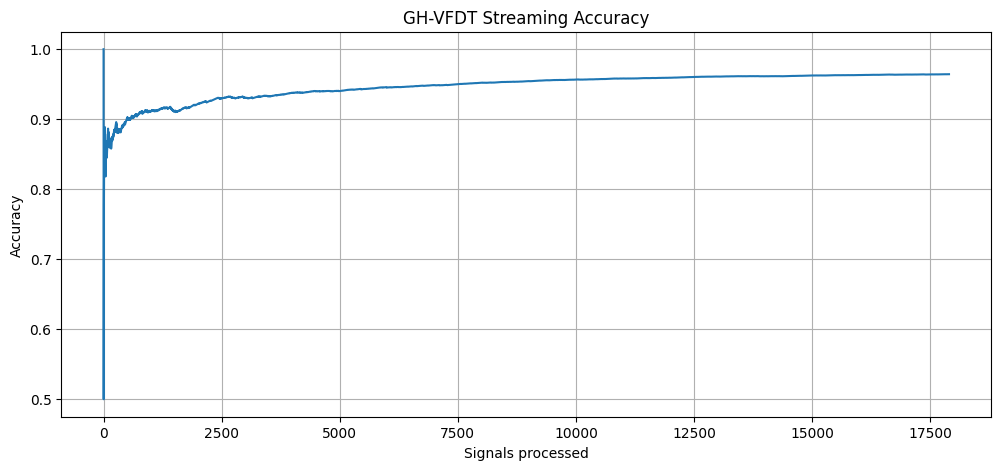

In [51]:
plt.figure(figsize=(12,5))
plt.plot(accuracy)
plt.title("GH-VFDT Streaming Accuracy")
plt.xlabel("Signals processed")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [52]:
print("Original rows:", len(df))
print("Candidates kept:", len(saved_candidates))
print("Discarded:", discarded)

Original rows: 17898
Candidates kept: 1354
Discarded: 16544


Confusion Matrix:
[[16082   177]
 [  462  1177]]


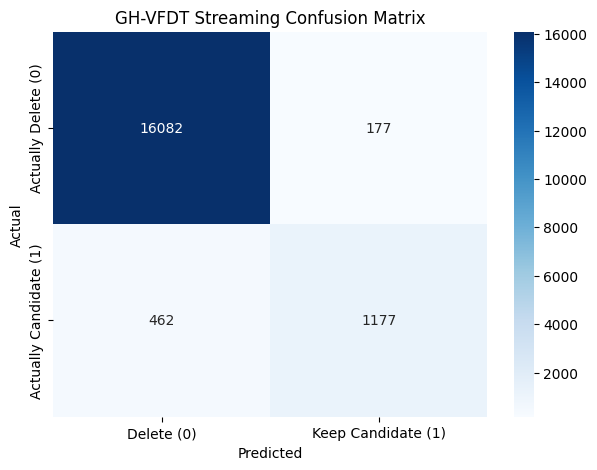

In [53]:
cm = confusion_matrix(y_true_all, y_pred_all)

print("Confusion Matrix:")
print(cm)

# plot
plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Delete (0)', 'Keep Candidate (1)'],
    yticklabels=['Actually Delete (0)', 'Actually Candidate (1)']
)

plt.title("GH-VFDT Streaming Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()